# Pipeline demo (cyclic attractor): Boolean model → STG → attractors → MaBoSS

Same pipeline as `pipeline_demo.ipynb`, on a toy network built so that starvation has **two kinds of attractor**:
a **fixed point** (Apoptosis) and a **cyclic attractor** (an autophagy oscillation).

In [1]:
import itertools, os
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
import mpbn, maboss

os.makedirs("figures", exist_ok=True)
GREEN, RED = "#2a9d8f", "#e63946"
PHENO = {"Autophagy": "#2a9d8f", "Apoptosis": "#e63946", "Proliferation": "#457b9d", "transient": "#d9d9d9"}
KIND = {"Autophagy": "cyclic", "Apoptosis": "fixed point", "Proliferation": "fixed point"}
NODE_COL = {"MTOR": "#457b9d", "ULK1": "#e9a03b", "BECN1": "#2a9d8f", "CASP3": "#e63946"}

## 1. Boolean model

- `MTOR ⊣ ULK1 → BECN1 → MTOR` is a **negative feedback loop**: autophagy recycles amino acids, which re-activates MTOR,
  which then shuts autophagy down. Negative loops are what give rise to cyclic attractors.
- `CASP3` sustains itself (caspase amplification, the point of no return), which is a **positive loop**. Together with the
  `BECN1 ⊣ CASP3 ⊣ BECN1` mutual inhibition, this gives the alternative fixed point.

In [2]:
rules = {
    "Nutrients": "Nutrients",
    "MTOR":      "Nutrients | BECN1",
    "ULK1":      "!MTOR",
    "BECN1":     "ULK1 & !CASP3",
    "CASP3":     "CASP3 & !MTOR & !BECN1",
}
with open("toy_model_cyclic.bnet", "w") as f:
    f.write("targets, factors\n" + "".join(f"{k}, {v}\n" for k, v in rules.items()))
nodes = list(rules)
print(open("toy_model_cyclic.bnet").read())

targets, factors
Nutrients, Nutrients
MTOR, Nutrients | BECN1
ULK1, !MTOR
BECN1, ULK1 & !CASP3
CASP3, CASP3 & !MTOR & !BECN1



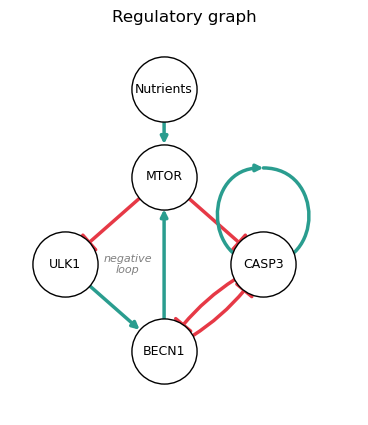

In [3]:
edges = [("Nutrients","MTOR",+1), ("BECN1","MTOR",+1), ("MTOR","ULK1",-1), ("ULK1","BECN1",+1),
         ("CASP3","BECN1",-1), ("BECN1","CASP3",-1), ("MTOR","CASP3",-1), ("CASP3","CASP3",+1)]
G = nx.DiGraph([(s, t, {"sign": w}) for s, t, w in edges])
pos = {"Nutrients": (0, 2), "MTOR": (0, 1), "ULK1": (-0.9, 0), "BECN1": (0, -1), "CASP3": (0.9, 0)}

fig, ax = plt.subplots(figsize=(4.5, 5))
nx.draw_networkx_nodes(G, pos, node_size=2200, node_color="white", edgecolors="black", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
for s, t, d in G.edges(data=True):
    pos_e = d["sign"] > 0
    nx.draw_networkx_edges(G, pos, [(s, t)], node_size=2200, width=2.5, ax=ax,
                           edge_color=GREEN if pos_e else RED,
                           arrowstyle="-|>" if pos_e else "|-|,widthA=0,widthB=0.7",
                           connectionstyle="arc3,rad=0.15" if {s, t} == {"BECN1", "CASP3"} else "arc3")
ax.text(-0.33, 0, "negative\nloop", ha="center", va="center", fontsize=8, style="italic", color="grey")
ax.set_title("Regulatory graph"); ax.axis("off"); ax.margins(0.2)
fig.savefig("figures/cyclic_1_regulatory_graph.png", dpi=300, bbox_inches="tight")

## 2. State transition graph (asynchronous, whole system)

All 5 nodes are free, giving 2⁵ = 32 states. `Nutrients` is an input (`Nutrients = Nutrients`), so it never changes and the
STG splits into two disconnected halves, one for `Nutrients = 0` and one for `Nutrients = 1`.

In [4]:
def evaluate(rule, s):
    expr = rule.replace("!", " not ").replace("&", " and ").replace("|", " or ")
    return int(eval(expr, {}, s))

def async_stg(rules, fixed):
    free = [n for n in rules if n not in fixed]
    stg = nx.DiGraph()
    for bits in itertools.product([0, 1], repeat=len(free)):
        s = {**fixed, **dict(zip(free, bits))}
        src = tuple(s[n] for n in free)
        stg.add_node(src)
        for n in free:
            v = evaluate(rules[n], s)
            if v != s[n]:
                stg.add_edge(src, tuple(v if m == n else s[m] for m in free))
    return stg, free

stg, free = async_stg(rules, fixed={})
print("variables:", free, "| states:", stg.number_of_nodes(), "| transitions:", stg.number_of_edges())

variables: ['Nutrients', 'MTOR', 'ULK1', 'BECN1', 'CASP3'] | states: 32 | transitions: 60


In [5]:
def phenotype(a):
    if len(a) > 1: return "Autophagy"
    return "Apoptosis" if dict(zip(free, a[0]))["CASP3"] else "Proliferation"

attractors = [sorted(a) for a in nx.attracting_components(stg)]
att_pheno = [phenotype(a) for a in attractors]
att_of = {s: i for i, a in enumerate(attractors) for s in a}
basin = {s: [i for i, a in enumerate(attractors) if any(nx.has_path(stg, s, t) for t in a)] for s in stg}
for a, ph in zip(attractors, att_pheno):
    print(f"{ph:14s} {KIND[ph]:12s} {len(a)} state(s): {[''.join(map(str, s)) for s in a]}")

Autophagy      cyclic       6 state(s): ['00000', '00100', '00110', '01000', '01010', '01110']
Apoptosis      fixed point  1 state(s): ['00101']
Proliferation  fixed point  1 state(s): ['11000']


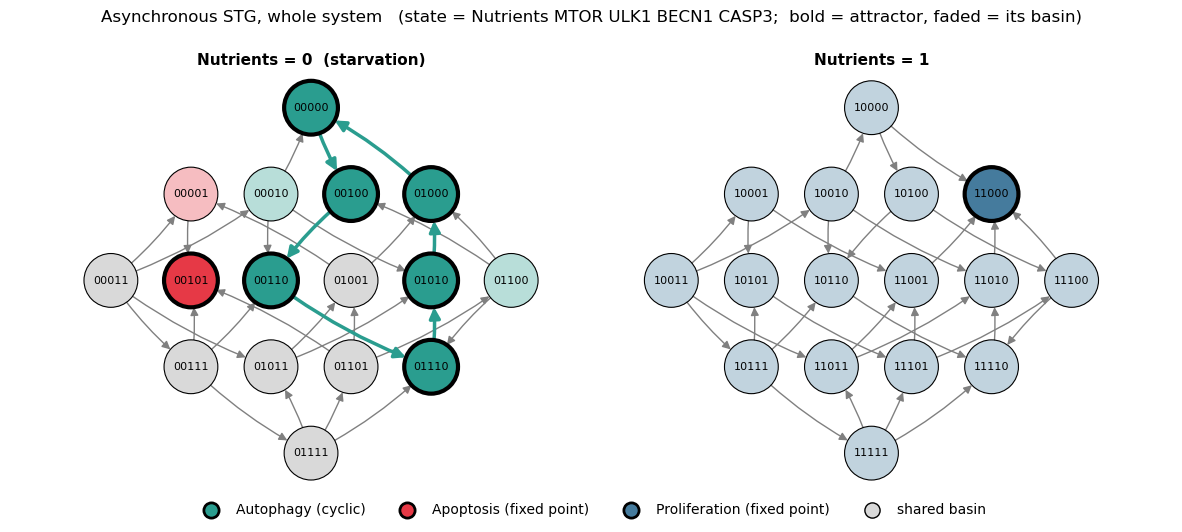

In [6]:
# lay each Nutrients half out by number of active nodes (Hamming layers)
pos_stg = {}
for nut, x0 in [(0, -3.5), (1, 3.5)]:
    layers = {}
    for s in stg:
        if s[0] == nut: layers.setdefault(sum(s[1:]), []).append(s)
    pos_stg.update({s: (x0 + i - (len(L) - 1) / 2, -k) for k, L in layers.items() for i, s in enumerate(sorted(L))})

colors = []
for s in stg:
    if s in att_of: colors.append(PHENO[att_pheno[att_of[s]]])
    elif len(basin[s]) == 1: colors.append(PHENO[att_pheno[basin[s][0]]] + "55")
    else: colors.append(PHENO["transient"])
cyc_edges = [(u, v) for u, v in stg.edges if u in att_of and att_of[u] == att_of.get(v) and len(attractors[att_of[u]]) > 1]

fig, ax = plt.subplots(figsize=(15, 6))
nx.draw_networkx_edges(stg, pos_stg, [e for e in stg.edges if e not in cyc_edges], node_size=1500,
                       edge_color="grey", arrowsize=12, ax=ax, connectionstyle="arc3,rad=0.08")
nx.draw_networkx_edges(stg, pos_stg, cyc_edges, node_size=1500, edge_color=PHENO["Autophagy"], width=2.5,
                       arrowsize=16, ax=ax, connectionstyle="arc3,rad=0.08")
nx.draw_networkx_nodes(stg, pos_stg, node_size=1500, node_color=colors, edgecolors="black",
                       linewidths=[3 if s in att_of else 0.8 for s in stg], ax=ax)
nx.draw_networkx_labels(stg, pos_stg, {s: "".join(map(str, s)) for s in stg}, font_size=8, ax=ax)
for x0, t in [(-3.5, "Nutrients = 0  (starvation)"), (3.5, "Nutrients = 1")]:
    ax.text(x0, 0.55, t, ha="center", va="center", fontsize=11, fontweight="bold")
ax.set_ylim(-4.45, 0.9)
for ph in ["Autophagy", "Apoptosis", "Proliferation"]:
    ax.scatter([], [], c=PHENO[ph], s=120, edgecolors="black", linewidths=2, label=f"{ph} ({KIND[ph]})")
ax.scatter([], [], c=PHENO["transient"], s=120, edgecolors="black", label="shared basin")
ax.legend(loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.08))
ax.set_title(f"Asynchronous STG, whole system   (state = {' '.join(free)};  bold = attractor, faded = its basin)")
ax.axis("off")
fig.savefig("figures/cyclic_2_state_transition_graph.png", dpi=300, bbox_inches="tight")

## 3. Attractors per scenario

mpbn uses **most-permissive** semantics. It reports fixed points as 0/1 and the cyclic attractor as a minimal **trap space**,
with the oscillating nodes shown as `*`. The trap space `MTOR=ULK1=BECN1=*` covers 8 states, but the asynchronous cyclic
attractor found in the STG holds only 6 of them. `(MTOR, ULK1, BECN1) = (0,0,1)` and `(1,1,0)` lie inside the trap space
yet are transient in the asynchronous dynamics.

In [7]:
bn = mpbn.MPBooleanNetwork("toy_model_cyclic.bnet")
rows = []
for scenario, nut in {"Nutrients ON": 1, "Starvation": 0}.items():
    bn["Nutrients"] = nut
    for i, a in enumerate(bn.attractors()):
        rows.append({"scenario": scenario, "attractor": f"{scenario} #{i+1}", **{n: a[n] for n in nodes}})
bn["Nutrients"] = "Nutrients"
att = pd.DataFrame(rows).set_index("attractor")
att

,scenario,Nutrients,MTOR,ULK1,BECN1,CASP3
attractor,,,,,,
Nutrients ON #1,Nutrients ON,1,1,0,0,0
Starvation #1,Starvation,0,0,1,0,1
Starvation #2,Starvation,0,*,*,*,0


In [8]:
# the asynchronous cyclic attractor, states listed in the order they are visited
cycle = next(a for a in attractors if len(a) > 1)
order = [cycle[0]]
while len(order) < len(cycle):
    order.append(next(v for v in stg.successors(order[-1]) if v in cycle))
pd.DataFrame(order, columns=free).rename_axis("step")

,Nutrients,MTOR,ULK1,BECN1,CASP3
step,,,,,
0,0,0,0,0,0
1,0,0,1,0,0
2,0,0,1,1,0
3,0,1,1,1,0
4,0,1,0,1,0
5,0,1,0,0,0


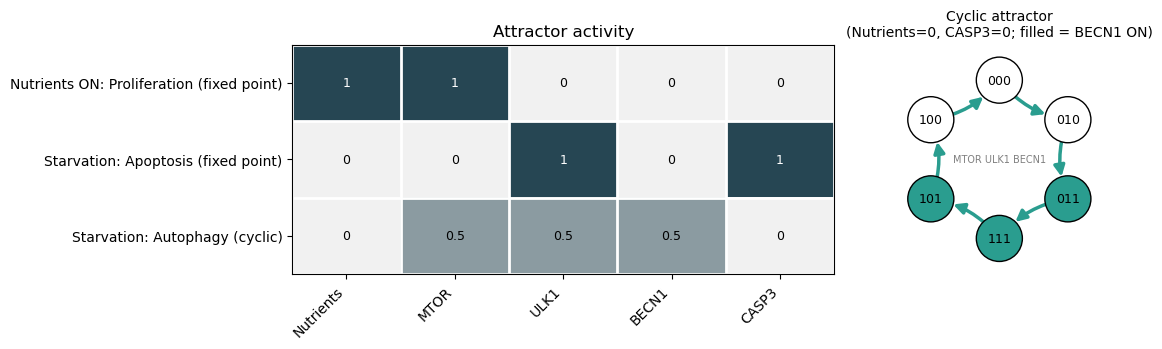

In [9]:
# attractor table: 0/1 for fixed points, mean activity (fraction of states ON) for the cyclic one
scen = {0: "Starvation", 1: "Nutrients ON"}
act = pd.DataFrame([pd.DataFrame(a, columns=free).mean() for a in attractors],
                   index=[f"{scen[a[0][0]]}: {ph} ({KIND[ph]})" for a, ph in zip(attractors, att_pheno)]).sort_index()

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.5, 1]})
cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list("act", ["#f1f1f1", "#264653"])
ax.imshow(act.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")
for (y, x), v in np.ndenumerate(act.values):
    ax.text(x, y, f"{v:.2g}", ha="center", va="center", color="white" if v > 0.6 else "black", fontsize=9)
ax.set_xticks(range(len(free)), free, rotation=45, ha="right")
ax.set_yticks(range(len(act)), act.index)
ax.set_xticks(np.arange(-.5, len(free)), minor=True); ax.set_yticks(np.arange(-.5, len(act)), minor=True)
ax.grid(which="minor", color="white", linewidth=2); ax.tick_params(which="minor", length=0)
ax.set_title("Attractor activity")

# the cycle as a ring; filled = BECN1 ON (autophagy active)
ring = nx.DiGraph(list(zip(order, order[1:] + order[:1])))
ang = np.pi / 2 - 2 * np.pi * np.arange(len(order)) / len(order)
pos_ring = {s: (np.cos(a), np.sin(a)) for s, a in zip(order, ang)}
idx = [free.index(n) for n in ["MTOR", "ULK1", "BECN1"]]
nx.draw_networkx_edges(ring, pos_ring, node_size=1100, edge_color=PHENO["Autophagy"], width=2.5, arrowsize=16,
                       connectionstyle="arc3,rad=0.2", ax=ax2)
nx.draw_networkx_nodes(ring, pos_ring, node_size=1100, edgecolors="black", ax=ax2,
                       node_color=[PHENO["Autophagy"] if s[free.index("BECN1")] else "white" for s in order])
nx.draw_networkx_labels(ring, pos_ring, {s: "".join(str(s[i]) for i in idx) for s in order}, font_size=9, ax=ax2)
ax2.text(0, 0, "MTOR ULK1 BECN1", ha="center", va="center", fontsize=7, color="grey")
ax2.set_title("Cyclic attractor\n(Nutrients=0, CASP3=0; filled = BECN1 ON)", fontsize=10)
ax2.set_xlim(-1.45, 1.45); ax2.set_ylim(-1.45, 1.45); ax2.set_aspect("equal"); ax2.axis("off")
fig.tight_layout()
fig.savefig("figures/cyclic_3_attractors.png", dpi=300, bbox_inches="tight")

## 4. MaBoSS stochastic simulation

Each cell in the population oscillates with its own random timing, so the **population average** of a cyclic attractor
levels off at a plateau instead of oscillating. MTOR and BECN1 are each ON in 3 of the 6 cycle states, so they settle near
`0.5 × P(cycle)`. ULK1 sits higher because it is also ON in the apoptosis fixed point. The oscillation itself is only visible in **single trajectories**.

In [10]:
sim = maboss.loadBNet("toy_model_cyclic.bnet")
sim.update_parameters(max_time=20, time_tick=0.1, sample_count=5000, thread_count=4)
for n in nodes:
    sim.network.set_istate(n, [0.5, 0.5])
sim.network.set_output(["MTOR", "ULK1", "BECN1", "CASP3"])

results = {}
for scenario, nut in {"Nutrients ON": 1, "Starvation": 0}.items():
    s = sim.copy()
    s.network.set_istate("Nutrients", [1 - nut, nut])
    results[scenario] = s.run()

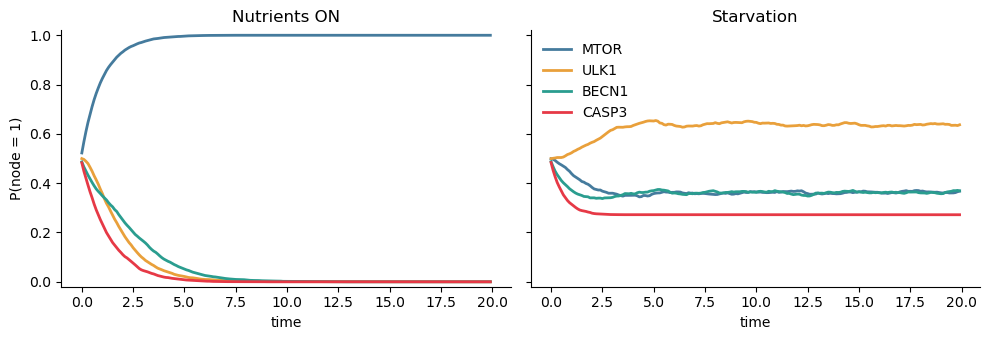

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, (scenario, res) in zip(axes, results.items()):
    nt = res.get_nodes_probtraj().reindex(columns=list(NODE_COL), fill_value=0)
    for n, c in NODE_COL.items():
        ax.plot(nt.index, nt[n], color=c, lw=2, label=n)
    ax.set_title(scenario); ax.set_xlabel("time"); ax.set_ylim(-0.02, 1.02)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("P(node = 1)"); axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig("figures/cyclic_4_maboss_trajectories.png", dpi=300, bbox_inches="tight")

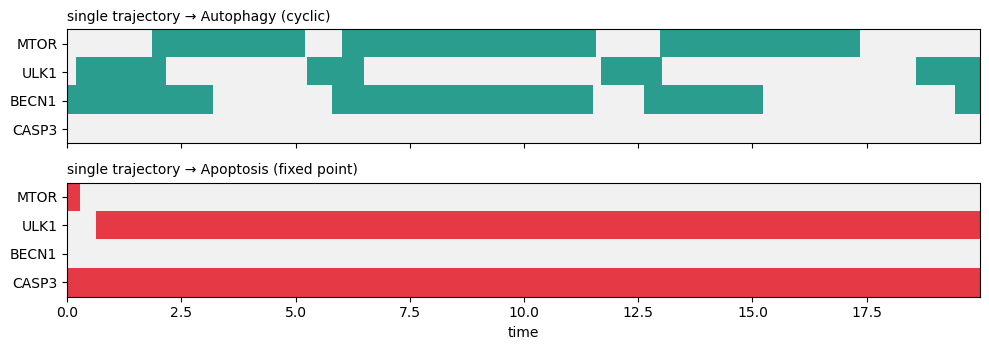

In [12]:
# single starvation trajectories: keep the first seed that ends in each attractor
one = sim.copy()
one.network.set_istate("Nutrients", [1, 0])
one.update_parameters(sample_count=1, thread_count=1, time_tick=0.02)
traces = {}
for seed in range(100):
    one.update_parameters(seed_pseudorandom=seed)
    nt = one.run().get_nodes_probtraj().reindex(columns=list(NODE_COL), fill_value=0)
    traces.setdefault("Apoptosis" if nt["CASP3"].iloc[-1] > 0.5 else "Autophagy", nt)
    if len(traces) == 2: break

fig, axes = plt.subplots(2, 1, figsize=(10, 3.6), sharex=True)
for ax, ph in zip(axes, ["Autophagy", "Apoptosis"]):
    nt = traces[ph]
    ax.imshow(nt.T.values, cmap=plt.matplotlib.colors.ListedColormap(["#f1f1f1", PHENO[ph]]), vmin=0, vmax=1,
              aspect="auto", interpolation="nearest", extent=[nt.index[0], nt.index[-1], len(NODE_COL) - .5, -.5])
    ax.set_yticks(range(len(NODE_COL)), list(NODE_COL))
    ax.set_title(f"single trajectory → {ph} ({KIND[ph]})", loc="left", fontsize=10)
axes[-1].set_xlabel("time")
fig.tight_layout()
fig.savefig("figures/cyclic_5_maboss_single_trajectories.png", dpi=300, bbox_inches="tight")

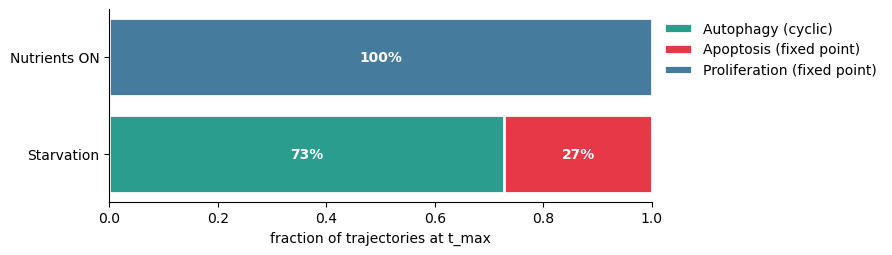

In [13]:
# assign every final MaBoSS state to the asynchronous attractor it belongs to
def classify(state, nut):
    on = set() if state == "<nil>" else set(state.split(" -- "))
    s = (nut,) + tuple(int(n in on) for n in free[1:])
    return att_pheno[att_of[s]] if s in att_of else "transient"

final = pd.DataFrame({sc: r.get_last_states_probtraj().iloc[0].groupby(lambda st: classify(st, nut)).sum()
                      for (sc, r), nut in zip(results.items(), [1, 0])}).fillna(0).T
final = final[[c for c in PHENO if c in final and final[c].max() > 0.005]]

fig, ax = plt.subplots(figsize=(7, 2.5))
left = np.zeros(len(final))
for ph in final.columns:
    v = final[ph].values
    ax.barh(final.index, v, left=left, color=PHENO[ph], edgecolor="white", lw=2, label=f"{ph} ({KIND.get(ph, 'not in an attractor')})")
    for y, (l, w) in enumerate(zip(left, v)):
        if w > 0.05: ax.text(l + w / 2, y, f"{w:.0%}", ha="center", va="center", color="white", fontweight="bold")
    left += v
ax.set_xlim(0, 1); ax.invert_yaxis(); ax.set_xlabel("fraction of trajectories at t_max")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc="upper left")
fig.savefig("figures/cyclic_6_maboss_final_states.png", dpi=300, bbox_inches="tight")